In [1]:
import numpy as np 
import scipy.stats as sp
import matplotlib.pyplot as plt 
from statsmodels.graphics import tsaplots

In [34]:
import re
def extract_values(filename, value_pattern):
    values = []
    with open(filename, 'r') as f:
        for line in f:
            # Extraire les valeurs spécifiques de la ligne
            line = line.strip('failure ')
            match = re.search(value_pattern, line)

            if match:
                values.append(match.group(0))  # Assumes value is in group 1
                # print(match.group(0))
    return np.array(values)

In [35]:
pt = 9.3e-4

### Estimation pour la dimension 5

- Noyau de proposition VAE  
- Mélange Gaussien de 300  
- Probabilité fixe p = 0.25 pour un échantillon de départ de 10000   
- Vamprior de K = 35


In [93]:
dim_5 = np.load('Resultats/Dim_5.npz')
samples_5 = dim_5['arr_0']
samples_5.shape

(5, 10000, 5)

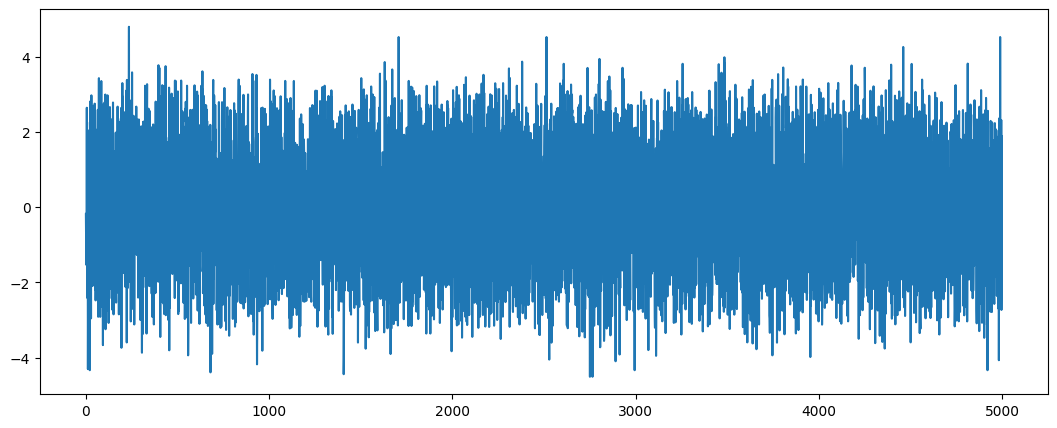

In [102]:
traj = samples_5[4]
plt.figure(figsize=(13,5))
plt.plot(traj[:5000, 3]) ; #Un bon mélange 

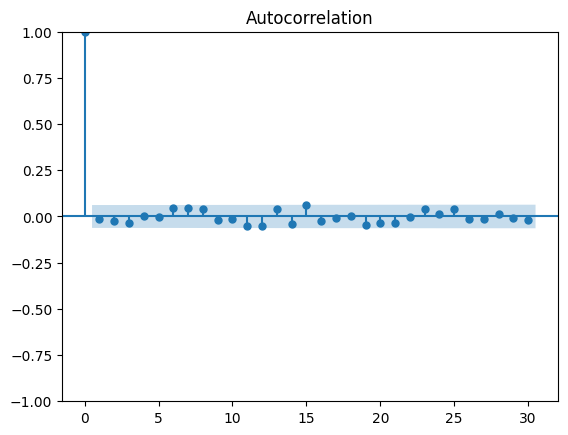

In [96]:
a= tsaplots.plot_acf(traj[:1000, 0])

In [114]:
estimation_d5 = extract_values('txtfiles/SSVAE_5.txt', '0.00...')

estimation_d5 = (estimation_d5).astype(float)
estimation_d5.shape

(41,)

In [115]:
cov_5 = np.round(estimation_d5.std()/ estimation_d5.mean(), 3)
cov_5

0.036

In [116]:
np.round(estimation_d5.mean(), 5)

0.00094

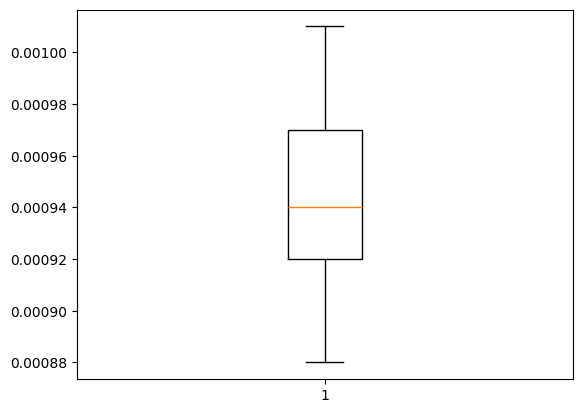

In [117]:
plt.boxplot(estimation_d5);

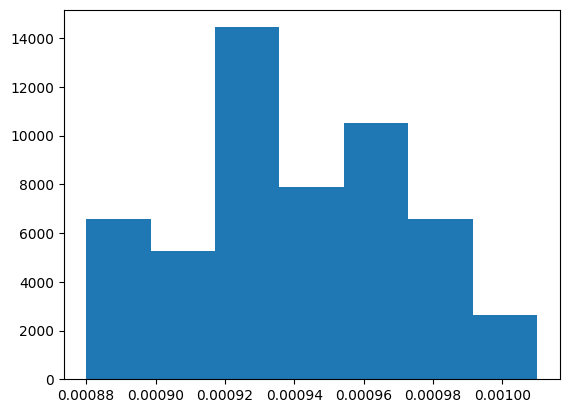

In [118]:
plt.hist(estimation_d5, density=True, bins='auto');


In [107]:
Nreq = int((1-pt)/(pt * cov_5**2))+1
print(f"Nreq = {Nreq} contre au maximum {210000} pour un run VAESS")

Nreq = 1117866 contre au maximum 210000 pour un run VAESS


In [108]:
Nreq/455000

2.4568483516483517

### Estimation pour la dimension 10

- Noyau de proposition VAE  
- Mélange Gaussien de 300  
- Probabilité fixe p = 0.25 pour un échantillon de départ de 1000   
- Vamprior de K = 35  
- Longueur de chaîne de 20

In [46]:
estimation_d10 = np.load('Resultats/Estimation10.npz')
cov_10 = np.round(estimation_d10['arr_0'].std() / estimation_d10['arr_0'].mean(), 3)
cov_10 #3.5% d'erreur 

0.035

In [26]:
Ntot = np.median(estimation_d10['arr_1'])
Ntot

446705.0

In [28]:
Nreq = int((1-pt)/ (pt*cov_10**2)) +1
print(Nreq)
np.round(Nreq/Ntot) #2 fois + pour un MCMC 

876955


2.0

In [30]:
np.round(estimation_d10['arr_0'].mean(), 5)

0.00095

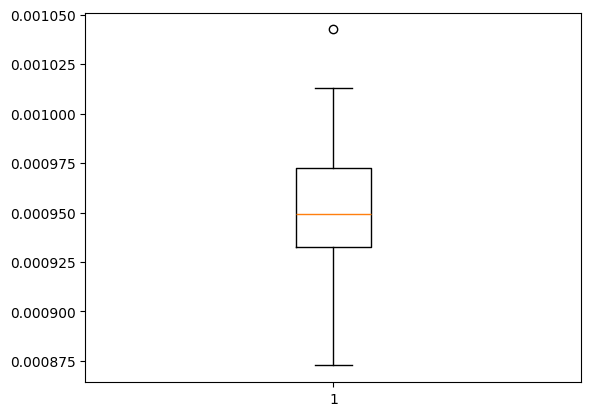

In [33]:
plt.boxplot(estimation_d10['arr_0']);

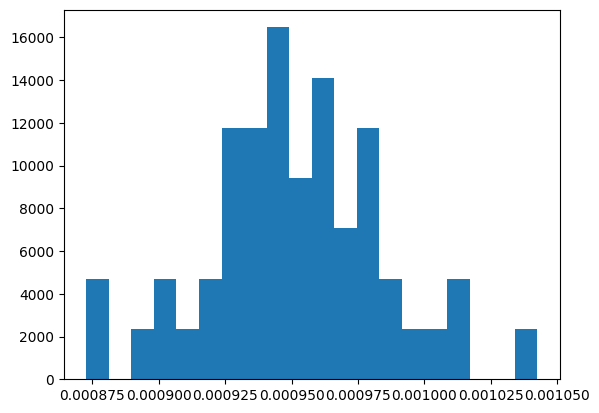

In [39]:
plt.hist(estimation_d10['arr_0'] , density=True, bins = 20);

In [41]:
estimation_d10 = extract_values('txtfiles/SSVAE_10.txt', '0.00...')
print(estimation_d10.shape)
# idx = np.where(estimation_d10 == '0.001 w')[0]
# estimation_d10[idx] = ['0.001']*len(idx)
# estimation_d10 = (estimation_d10).astype(float)
# cov_10 = np.round(estimation_d10.std() / estimation_d10.mean(), 3)
# cov_10

(172,)


### Estimation pour la dimension 20

- Noyau de proposition VAE  
- Mélange Gaussien de 300 gaussiennes  
- Probabilité fixe p = 0.25 pour un échantillon de départ de 10000   : soit 2500 échantillons d'entrainements 
- Vamprior de K = 35  
- Une longueur de chaîne de l = 25

In [72]:
dim_20 = np.load('Resultats/Dim_20.npz')
samples_20 = dim_20['arr_0']
samples_20.shape

(5, 10000, 20)

In [73]:
dim_20['arr_1']

array([0.34938, 0.26107, 0.22772, 0.19769, 0.18261])

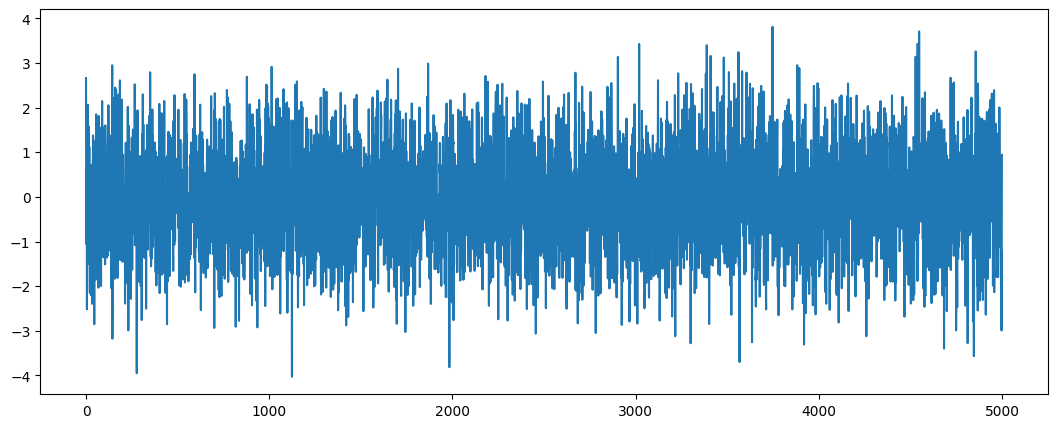

In [110]:
traj = samples_20[4]
plt.figure(figsize=(13,5))
plt.plot(traj[:5000, 3]) ;

In [8]:
estimation_d20 = extract_values('txtfiles/SSVAE_20.txt', '0.00...')
print(estimation_d20.shape)
idx = np.where(estimation_d20 == '0.001 w')[0]
estimation_d20[idx] = ['0.001']*len(idx)
estimation_d20 = (estimation_d20).astype(float)
cov_20 = np.round(estimation_d20.std() / estimation_d20.mean(), 3)
cov_20

(60,)


0.037

In [56]:
estimation_d20 = np.load('Resultats/Estimation20.npz')
cov_20  = estimation_d20['arr_0'].std() / estimation_d20['arr_0'].mean()
cov_20

0.038155795387042314

In [57]:
np.round(estimation_d20['arr_0'].mean(), 5)

0.00095

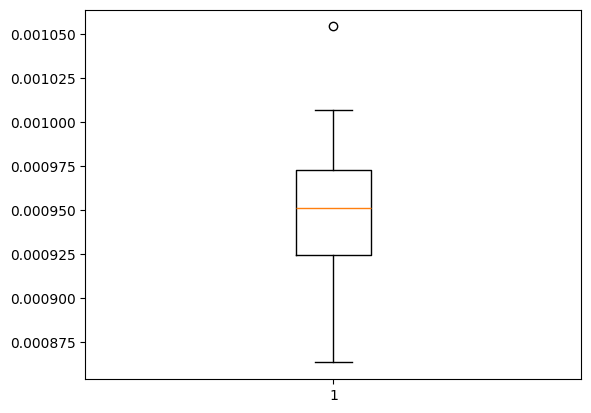

In [58]:
plt.boxplot(estimation_d20['arr_0']);

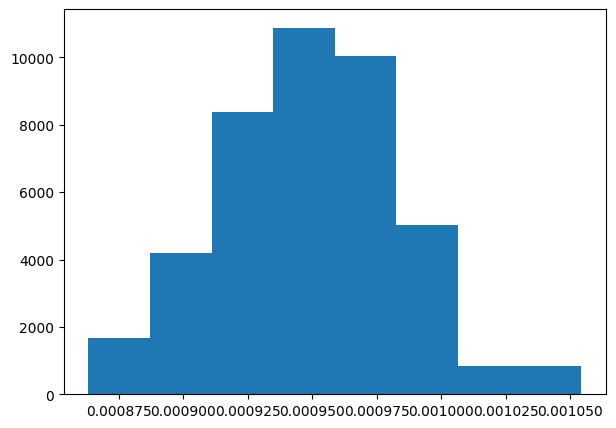

In [77]:
plt.figure(figsize=(7,5))
plt.hist((estimation_d20['arr_0']), density=True, bins='auto');

In [78]:
Ntot = np.mean(estimation_d20['arr_1'])
Ntot

730527.0

In [71]:
Nreq = int((1-pt)/ (pt*0.038**2)) +1
print(Nreq)
Nreq/Ntot

743954


1.0183798819208598

### Estimation pour la dimension 50

- Noyau de proposition VAE  
- Mélange Gaussien de 500  
- Probabilité fixe p = 0.25 pour un échantillon de départ de 10000   
- Vamprior de K = 35  


Avec une chaine **l = 25**

In [24]:
dim_50 = np.load('Resultats/Dim_50.npz')
samples_50 = dim_50['arr_0']
samples_50.shape

(5, 10000, 50)

In [25]:
dim_50['arr_1']

array([0.32714, 0.24776, 0.21345, 0.19468, 0.17501])

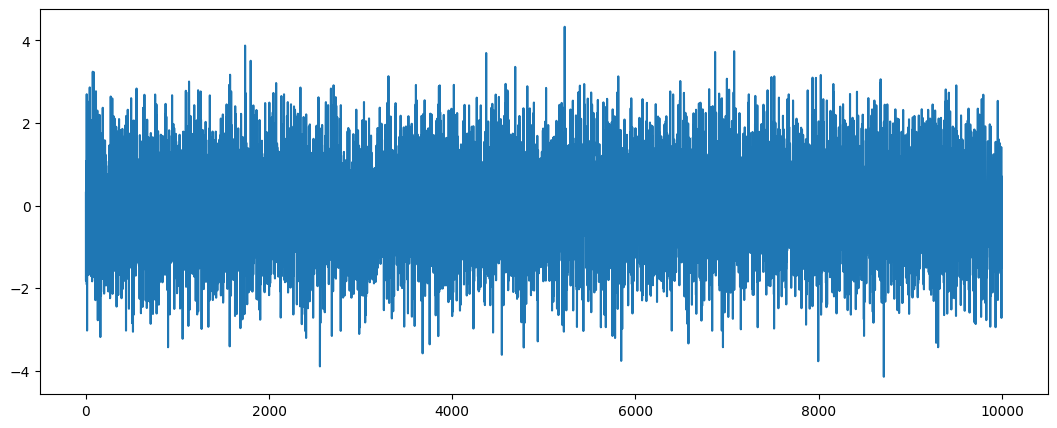

In [27]:
traj = samples_50[4]
plt.figure(figsize= (13,5))
plt.plot(traj[:, 0])

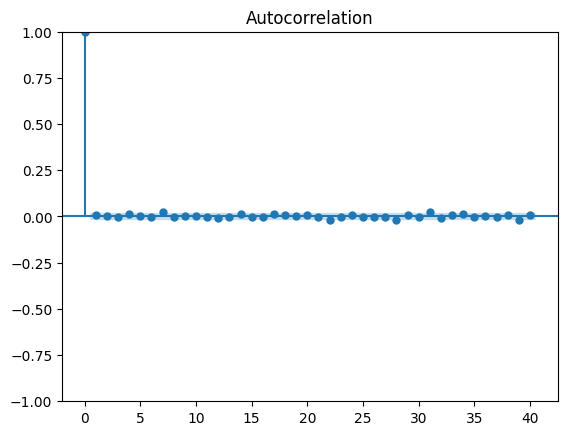

In [29]:
a = tsaplots.plot_acf(traj[:, 1])

In [46]:
estimation_d50 = np.load('Resultats/Estimation50.npz')
print(estimation_d50['arr_0'].mean(), '\n',
estimation_d50['arr_0'].shape)

0.00097078125 
 (15,)


In [43]:
cov_50_l25 = np.round(estimation_d50['arr_0'].std() /estimation_d50['arr_0'].mean(), 7)
cov_50_l25

0.033259

In [13]:
(f"Estmation avec {estimation_d50.shape[0]} : {np.round(estimation_d50.mean(), 5)}")

'Estmation avec 47 : 0.00101'

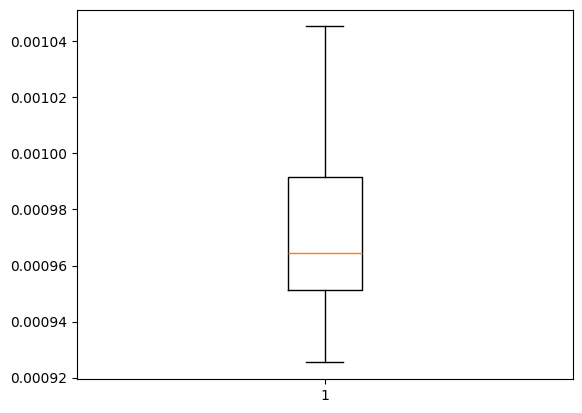

In [122]:
plt.boxplot(estimation_d50['arr_0']);

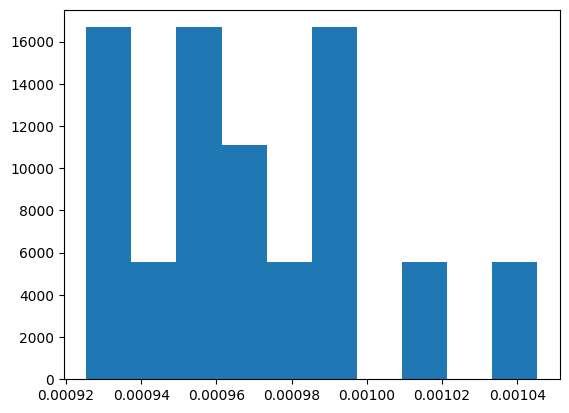

In [124]:
plt.hist(estimation_d50['arr_0'], density=True);

Avec une chaîne de longueur **l = 35**

In [32]:
estimation_d50_l35  = np.load('Resultats/Estimation50_l35.npz')
cov_50_l35 = np.round(estimation_d50_l35['arr_0'].std() / estimation_d50_l35['arr_0'].mean(), 7)
cov_50_l35

0.0284038

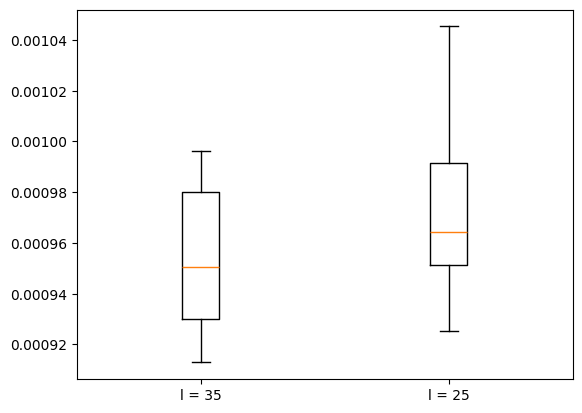

In [17]:
plt.boxplot([estimation_d50_l35['arr_0'], estimation_d50['arr_0']]);
plt.xticks([1, 2], ['l = 35', 'l = 25']);

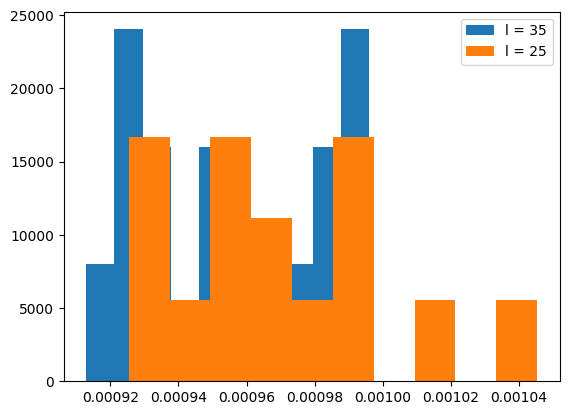

In [21]:
plt.hist(estimation_d50_l35['arr_0'], density=True, label= 'l = 35')
plt.hist(estimation_d50['arr_0'], density=True, label= 'l = 25');
plt.legend();

In [40]:
np.floor(estimation_d50_l35['arr_1'].mean())

987021.0

In [41]:
Nreq = int((1-pt)/ (pt*cov_50_l35**2)) +1
Nreq /987021

1.3490675477016194

In [48]:
np.floor(estimation_d50['arr_1'].mean())
estimation_d50['arr_1']

array([ 850758, 1051148, 1045820,  845516,  844056,  852668, 1043473,
       1049027, 1049646, 1046307,  853947, 1045394, 1047801, 1047136,
        842201], dtype=int64)

In [44]:
Nreq = int((1-pt)/ (pt*cov_50_l25**2)) +1
Nreq /987021

0.9839395514381153

In [12]:
estimation_d50 = extract_values('txtfiles/SSVAE_50.txt', '0.00...')
print(estimation_d50.shape)
idx = np.where(estimation_d50 == '0.001 w')[0]
estimation_d50[idx] = ['0.001']*len(idx)
estimation_d50 = (estimation_d50).astype(float)
cov_50 = np.round(estimation_d50.std() / estimation_d50.mean(), 3)
print(f"c.o.v : {cov_50}")

(47,)
c.o.v : 0.041


### Estimation pour la dimension 70

- Noyau de proposition VAE  
- Mélange Gaussien de 500  
- Probabilité fixe p = 0.25 pour un échantillon de départ de 1000   
- Vamprior de K = 35

In [21]:
estimation_d70 = extract_values('txtfiles/SSVAE__70.txt', '0.00...')
print(estimation_d70.shape)
idx = np.where(estimation_d70 == '0.001 w')[0]
estimation_d70[idx] = ['0.001']*len(idx)
estimation_d70 = (estimation_d70).astype(float)
cov_70 = np.round(estimation_d70.std() / estimation_d70.mean(), 3)
cov_70

(79,)


0.052

In [108]:
(1-sp.norm(loc = -5).cdf(0)) *4

1.1466062876941407e-06

In [3]:
Pf = 9.2
Nreq = 12
Ntot = 10
accep = [1,2,3,4]
d =10
l = 10

In [14]:
condition = [True, False]*5
condition

[True, False, True, False, True, False, True, False, True, False]